> **Open in Google Colab.** The next cell installs `coptpy`. The bundled free license is size-limited but covers this case. Then run *Runtime > Run all*.


In [ ]:
# COPT Python API and this case's dependencies
%pip install -q coptpy matplotlib numpy


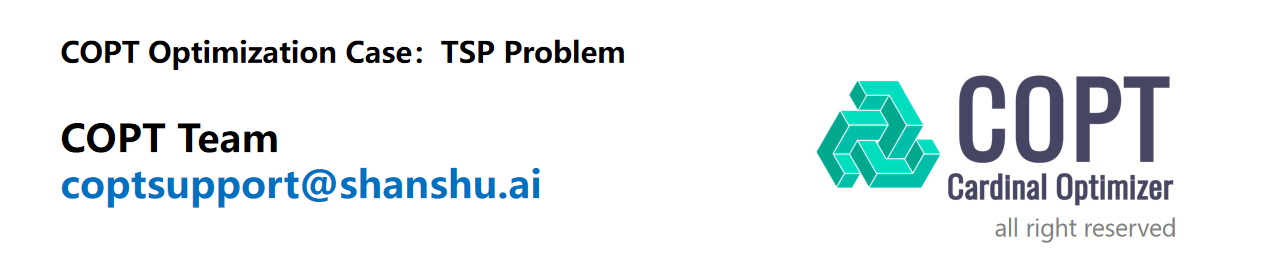

# TSP Problem Code Implementation

## Steps for Solving STSP Problems Using COPT Callback function

1. **Import the COPT-Python interface library** `coptpy`

2. Add/import model **data**: an artificial data set and real Chinese province longitude and latitude data

3. Create **Solving Environment** and Solving **Model**

4. Build the model and add the **three elements of the model** in sequence
    - **Decision Variables**: Integer type (0-1 type)
    - **Objective Function**
    - **Constraints**: 
      - the "symmetric" constraint and the "city only passes once" constraint
      - call the Callback function to implement the "eliminating subrings" constraints

5. **Solve**

6. View and analyze solution **results**


We will solve the STSP problem on an artificial data set and real Chinese province longitude and latitude data respectively. The distance (cost) in the problem adopts Euclidean distance.

### Artificial data set

#### Generate data

Here we use `numpy` to randomly generate coordinates of `nCities=20` cities on a two-dimensional plane. Each coordinate of each city is independent of each other and follows a uniform distribution on $[0,1]$.

- `cities` is a two-dimensional `numpy` array of $nCities\times 2$, and `cities[i]` records the two-dimensional coordinates of city $i$.

- `distances` is a Python dictionary, `distances[(i,j)]` records the Euclidean distance between city $i$ and city $j$, and `distances[(i,j)]=distances[(j,i)]`.
- `edges` is a Python list that records all edges `(i,j)`, a total of $n(n-1)$.

In [1]:
import numpy as np

np.random.seed(1)
nCities = 20
cities = np.random.rand(nCities, 2)
distances = dict()

for i in range(nCities):
    for j in range(i+1,nCities):
        distances[(i,j)] = np.linalg.norm(cities[i]-cities[j])
        distances[(j,i)] = distances[(i,j)]

edges = list(distances.keys())

We use `matplotlib` to visualize the locations of cities.

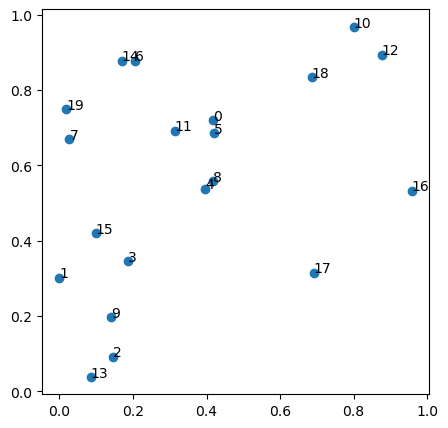

In [3]:
import time
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(5,5))
plt.scatter(cities[:,0],cities[:,1],marker='o')
for i in range(nCities):
    plt.text(cities[i,0],cities[i,1],i)
plt.show()

#### Create a COPT environment

You are probably already familiar with this step. We used `Envr()` to create a COPT environment and used `Env.createModel()` to create a model named `ip_stsp`.

In [5]:
from coptpy import *

# Create COPT environment
env = Envr()

# Create COPT model
model = env.createModel("ip_stsp")

Cardinal Optimizer v8.0.5. Build date May 30 2026
Copyright Cardinal Operations 2026. All Rights Reserved



#### Describe the problem to COPT

##### Add variables

Here we use `addVars()` to add 0-1 indicator variables to all edges, and the variable type is `COPT.BINARY`.

In [7]:
e = model.addVars(edges, vtype=COPT.BINARY, nameprefix='e')

##### Add some constraints

Let's first add the "symmetric" constraint and the "city only passes once" constraint
$$
\begin{aligned}
&\sum_{j\in V,j\neq i}x_{ij} = 2, &\forall i\in V \\
&x_{ij} = x_{ji}, &\forall i,j\in V,i\neq j
\end{aligned}
$$

For the summation form, we have seen the convenience of `tupledict.sum()` in the quick start, but $\forall i\in V$ may give you a headache. We can use the `for` loop plus `addConstr()` to achieve the task, but just like `addVar()` and `addVars()`, we can use the `addConstrs()` method to add constraints in batches more elegantly. `Model.addConstrs(generator, nameprefix="R")` can be used to add constraints in batches. You only need to use a syntax similar to Python list comprehension (`newlist = [expression for item in iterable if condition == True]`). The specific usage is clear at a glance just by looking at the example below.

In [9]:
model.addConstrs(e.sum(i,'*') == 2 for i in range(nCities))
model.addConstrs(e[i,j] == e[j,i] for i,j in edges)

#### Dealing with "eliminating subrings" constraints

It is not a wise idea to add "eliminating subrings" constraints directly to `model`. Let's first calculate how many "eliminating subrings" constraints there will be.
$$\frac{1}{2}\sum_{(i,j)\in S} x_{ij} \leq |S|-1, \forall S\subset V,3\leq |S| \leq n-2$$
We take the total number of subsets of the city set ($2^{n}$) minus the 0, 1, 2, $n-1$, and $n$ subsets:

In [11]:
2**nCities - 1 - nCities - nCities*(nCities-1)/2 - nCities - 1

1048344.0

With only `nCities=20` cities, there are already 1,048,344 "eliminate subrings" constraints! On the one hand, we don't want to add so many constraints directly, because this will make the problem very difficult to solve. On the other hand, the decision variables of the original problem are far less than the number of "eliminate subrings" constraints, which means that in the optimal solution of the original problem, most of the "eliminate subrings" constraints are unnecessary.

A common idea is **relaxation**. We simply "discard" some constraints to make the feasible set of the optimization problem larger. If the optimal solution under this new problem is still feasible in the original problem, then we have found the optimal solution of the original problem.

Specifically, the "eliminate subrings" constraint was originally intended to prevent subrings from appearing, but if we can find a path without subrings with the remaining constraints alone, then the original problem has been solved. **Relaxation** is worth a try!

##### Set the objective function

Before solving the problem, don't forget to add the objective function. $$
\min\ \sum_{i,j\in V,i\neq j} d_{ij}x_{ij}
$$
Although we have been able to use `tupledict.sum()` to handle the summation, this time the summation is with the coefficient $d_{ij}$, and `tupledict.sum()` seems to be less convenient to use. COPT anticipated this situation and provided us with the `tupledict.prod(coeff, pattern)` function. Recall the structure of the dictionary `distances`, its key $(i,j)$ matches the key of the `tupledict` object `e` of the decision variable, so using `e.prod(distances)` will multiply $x_{ij}$ with $d_{ij}$ and add the results, which is exactly what we want.

In [13]:
model.setObjective(e.prod(distances),sense=COPT.MINIMIZE)

**Define search subloop function**

In [15]:
# Given a tuplelist of edges, find the shortest subtour
def subtour(vals):
    # make a list of edges selected in the solution
    edges = tuplelist((i, j) for i, j in vals.keys()
                         if vals[i, j] > 0.5)
    unvisited = list(range(nCities))

    # initial length has 1 more city
    cycle = range(nCities+1)
    while unvisited:  # true if list is non-empty
        thiscycle = []
        neighbors = unvisited
        while neighbors:
            current = neighbors[0]
            thiscycle.append(current)
            unvisited.remove(current)
            neighbors = [j for i, j in edges.select(current, '*')
                         if j in unvisited]
        if len(cycle) > len(thiscycle):
            cycle = thiscycle
    return cycle

**Define callback class and its member functions**

In [17]:
# Define the callback class
class CoptCallback(CallbackBase):
    def __init__(self, vars):
        super().__init__()
        self.vars = vars

    def callback(self):
        if self.where() == COPT.CBCONTEXT_MIPSOL:
            vars = self.vars
            vals = self.getSolution(vars) # vals is a tupledict (feasible solution)
            tour = subtour(vals)
            if len(tour) < nCities:
                self.addLazyConstr(quicksum(vars[tour[i], tour[i+1]] for i in range(len(tour)-1)) + vars[tour[-1], tour[0]] <= len(tour)-1)

**Call callback function**

In [19]:
cb = CoptCallback(e)
model.setCallback(cb, COPT.CBCONTEXT_MIPSOL)
model.solve()

Model fingerprint: 485fcf87

Using Cardinal Optimizer v8.0.5 on Windows (22H2 Build 19045 - x86_64)
The CPU model is Intel(R) Core(TM) i5-10210U CPU @ 1.60GHz
Hardware has 4 physical cores and 8 logical cores. Using instruction set X86_AVX2 (10)
Minimizing a MIP problem

The original problem has:
    400 rows, 380 columns and 1140 non-zero elements
    380 binaries

Starting the MIP solver with 8 threads and 32 tasks

Presolving the problem

The presolved problem has:
    20 rows, 190 columns and 380 non-zero elements
    190 binaries

Problem info:
    Range of matrix coefficients:    [1e+00,1e+00]
    Range of rhs coefficients:       [2e+00,2e+00]
    Range of bound coefficients:     [1e+00,1e+00]
    Range of cost coefficients:      [6e-02,2e+00]
    Density of cost:                     100.0%

     Nodes    Active  LPit/n  IntInf     BestBound  BestSolution     Gap   Time
         0         1      --       0  0.000000e+00            --     Inf  0.02s
         0         1      --   

#### View the results

We define two functions `get_path()` and `draw_path()`.

- `get_path()` can get the selected path from the optimal solution

- `draw_path()` will draw the selected path

Among them, in `get_path()` we encountered some new and old faces of COPT.

- We have seen `getVars()`, which can get model variables to further obtain variable information.
- `var.x` can access the optimal value of the variable, and we have also seen `var.name` and so on.
- `model.Param.IntTol` is one of the built-in parameter constants of COPT. For numerical stability, the solver often introduces tolerance, so even if it is a 0-1 variable, `var.x` may take a value like $0.999999$ in the optimal solution. At this time, if you directly judge `var.x == 1`, you will get `False`, so tolerance judgment is also used here. COPT has many more parameter constants. We recommend that you refer to the <a href="https://www.shanshu.ai/copt-document/manual?id=19&docType=3" target="_blank" >COPT Python API</a> for more information.
- `var.getIdx()` has the same function as `var.index`, both of which can access the variable index. Here, the order of $x_{ij}$ in the model variables is consistent with the order of its corresponding edge $(i,j)$ in `edges`.

In [21]:
def get_path():
    '''
    get path from optimal solution
    '''
    path = []
    allvars = model.getVars()
    
    for var in allvars:
        if var.x >= 1 - model.Param.IntTol:
            path.append(edges[var.getIdx()])
            
    return path

def draw_path():
    '''
    draw the path
    '''
    path = get_path()

    plt.figure(figsize=(5,5))
    plt.scatter(cities[:,0],cities[:,1],marker='o')
    
    for i in range(nCities):
        plt.text(cities[i,0],cities[i,1],i)
        
    for i in path:
        plt.plot([cities[i[0],0],cities[i[1],0]],[cities[i[0],1],cities[i[1],1]], color='red')

    plt.show()

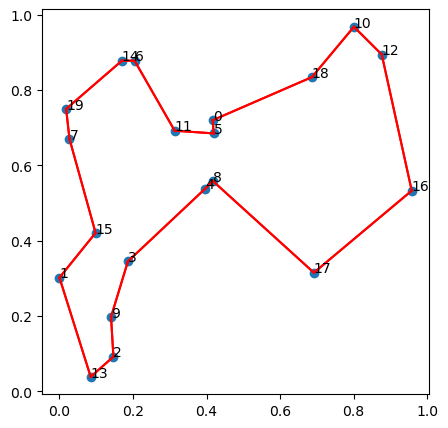

7.342306618738267

In [23]:
draw_path()
model.objval

So far, we have cooperated with COPT and completed an attempt to solve the STSP problem. We called the Callback function of COPT 6.5 to implement the algorithm idea of ​​gradually eliminating sub-rings. Next, we will use the real longitude and latitude data of various provinces in China to establish the STSP problem, review the method we just used, and complete a **travel around China**.

### Chinese province longitude and latitude data

#### Data preparation

Use the real latitude and longitude data of each province in China to create `nCities`, `cities`, `city_list`, `distances` and `edges` accordingly.

In [25]:
provinces = {
    '吉林省': [125.326800, 43.896160], '黑龙江省': [126.662850, 45.742080],
    '辽宁省': [123.429250, 41.835710], '内蒙古自治区': [111.765220, 40.817330],
    '新疆维吾尔自治区': [87.627100, 43.793430], '青海省': [101.780110, 36.620870],
    '北京市': [116.407170, 39.904690], '天津市': [117.199370, 39.085100],
    '上海市': [121.473700, 31.230370], '重庆市': [106.550730, 29.564710],
    '河北省': [114.469790, 38.035990], '河南省': [113.753220, 34.765710],
    '陕西省': [108.954240, 34.264860], '江苏省': [118.762950, 32.060710],
    '山东省': [117.020760, 36.668260], '山西省': [112.562720, 37.873430],
    '甘肃省': [103.826340, 36.059420], '宁夏回族自治区': [106.258670, 38.471170],
    '四川省': [104.075720, 30.650890], '西藏自治区': [91.117480, 29.647250],
    '安徽省': [117.285650, 31.861570], '浙江省': [120.153600, 30.265550],
    '湖北省': [114.342340, 30.545390], '湖南省': [112.983400, 28.112660],
    '福建省': [119.296590, 26.099820], '江西省': [115.910040, 28.674170],
    '贵州省': [106.707220, 26.598200], '云南省': [102.709730, 25.045300],
    '广东省': [113.266270, 23.131710], '广西壮族自治区': [108.327540, 22.815210],
    '香港': [114.165460, 22.275340], '澳门': [113.549130, 22.198750],
    '海南省': [110.348630, 20.019970], '台湾省': [121.520076, 25.030724],
}

nCities = len(provinces)
city_list = list(provinces.keys())
cities = np.array(list(provinces.values()))
distances = dict()

for i in range(nCities):
    for j in range(i+1,nCities):
        distances[(i,j)] = np.linalg.norm(np.array(provinces[city_list[i]])-np.array(provinces[city_list[j]]))
        distances[(j,i)] = distances[(i,j)]

edges = list(distances.keys())

#### Describe the relaxation problem

Here we need to use `model.clear()` to clear the previously constructed model, and then add new variables and constraints. Here we still do not add the "eliminate subring" constraint.

In [27]:
model.clear()

e = model.addVars(edges, vtype=COPT.BINARY, nameprefix='e')

model.addConstrs(e.sum(i,'*') == 2 for i in range(nCities))
model.addConstrs(e[i,j] == e[j,i] for i,j in edges)

model.setObjective(e.prod(distances),sense=COPT.MINIMIZE)

In [29]:
plt.rcParams['font.sans-serif'] = ['SimHei']
def draw_provinces():
    path = get_path()

    plt.figure(figsize=(16,9))
    plt.scatter(cities[:,0],cities[:,1],marker='o')
    
    for i in range(nCities):
        plt.text(cities[i,0],cities[i,1],city_list[i])
        
    for i in path:
        plt.plot([cities[i[0],0],cities[i[1],0]],[cities[i[0],1],cities[i[1],1]], color='red')

    plt.show()

**Call callback function**

In [31]:
cb = CoptCallback(e)
model.setCallback(cb, COPT.CBCONTEXT_MIPSOL)
model.solve()

Model fingerprint: 372b0d09

Using Cardinal Optimizer v8.0.5 on Windows (22H2 Build 19045 - x86_64)
The CPU model is Intel(R) Core(TM) i5-10210U CPU @ 1.60GHz
Hardware has 4 physical cores and 8 logical cores. Using instruction set X86_AVX2 (10)
Minimizing a MIP problem

The original problem has:
    1156 rows, 1122 columns and 3366 non-zero elements
    1122 binaries

Starting the MIP solver with 8 threads and 32 tasks

Presolving the problem

The presolved problem has:
    34 rows, 561 columns and 1122 non-zero elements
    561 binaries

Problem info:
    Range of matrix coefficients:    [1e+00,1e+00]
    Range of rhs coefficients:       [2e+00,2e+00]
    Range of bound coefficients:     [1e+00,1e+00]
    Range of cost coefficients:      [1e+00,8e+01]
    Density of cost:                     100.0%

     Nodes    Active  LPit/n  IntInf     BestBound  BestSolution     Gap   Time
         0         1      --       0  0.000000e+00            --     Inf  0.10s
         0         1      -

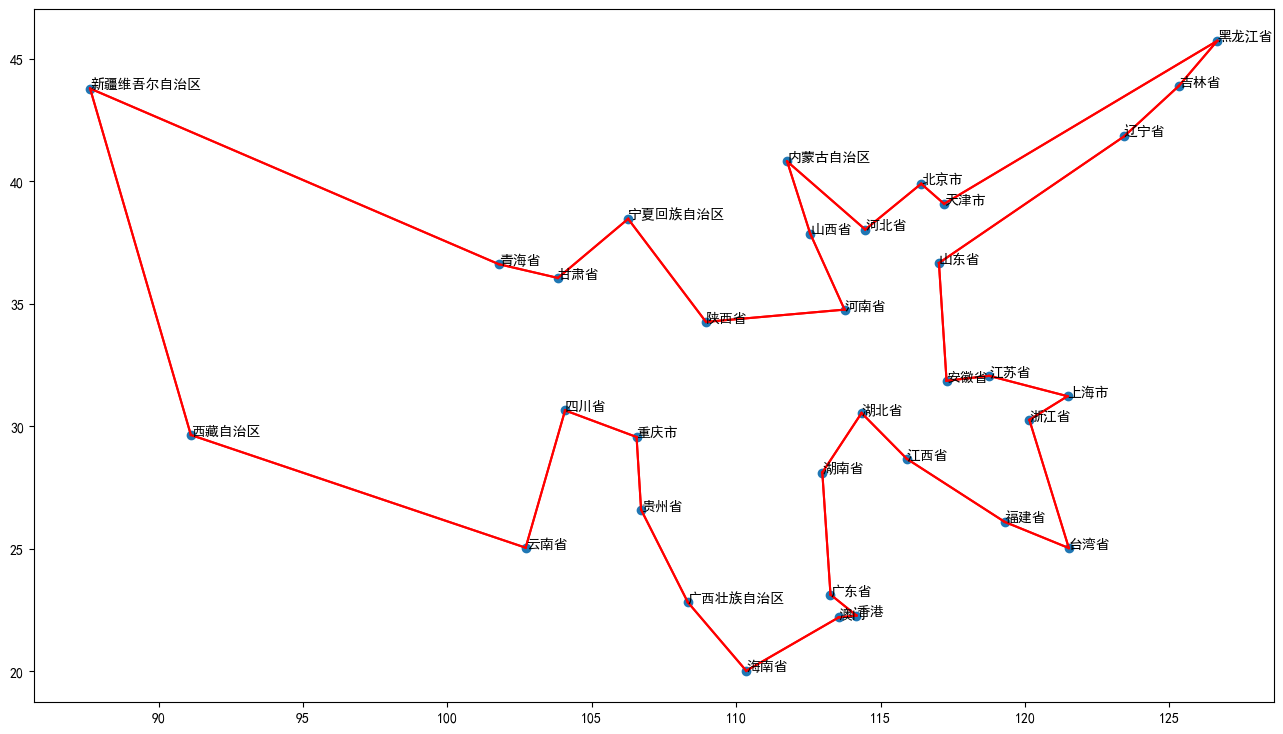

In [33]:
if model.status == COPT.OPTIMAL: 
    draw_provinces()